<a href="https://colab.research.google.com/github/Heet06/MLUP001/blob/main/Week-4/Assignment/Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[Problem Description](https://drive.google.com/file/d/19U_wXTZcpsY5yJh_gHSxO6Vrm1zOEhAc/view?usp=sharing)
---

Import Necessary Libraries

In [166]:
import numpy as np
import pandas as pd

In [167]:
# Load Data
stock_data1 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Assignment - 4/Stock_File_1.csv')
stock_data2 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Assignment - 4/Stock_File_2.txt')

In [168]:
# Check for duplicate records

print(len(stock_data1))

print(len(np.unique(stock_data1.Date)))

print(len(stock_data2))
print(len(np.unique(stock_data2.Date)))

165
165
204
204


In [169]:
# Concatenate both the datasets into one dataset for easier handling

stock_data = pd.concat([stock_data1, stock_data2], ignore_index=True)

stock_data_cp = stock_data.copy()

stock_data_cp.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')

In [170]:
# Let's explore the data inside the df

stock_data_cp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 369 entries, 0 to 368
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    369 non-null    object 
 1   Open    362 non-null    float64
 2   High    353 non-null    float64
 3   Low     356 non-null    float64
 4   Close   355 non-null    float64
 5   Volume  369 non-null    object 
dtypes: float64(4), object(2)
memory usage: 17.4+ KB


- Volume shows as object but it should int
- There are missing values in few variables

In [171]:
# Format the 'Date' field in required format

stock_data_cp['Date'] = pd.to_datetime(stock_data_cp['Date'], format='%d-%b-%y')

stock_data_cp['Date']

,Date
0,2006-06-01
1,2006-06-12
2,2006-06-22
3,2006-07-03
4,2006-07-13
...,...
364,2016-07-11
365,2016-07-21
366,2016-08-01
367,2016-08-11


In [172]:
# Sort the data based on 'Date'

stock_data_cp.sort_values(by=['Date'], inplace=True)
stock_data_cp

,Date,Open,High,Low,Close,Volume
0,2006-06-01,471.60,474.00,442.00,444.42,21900
1,2006-06-12,454.00,464.00,440.00,446.17,8400
2,2006-06-22,451.16,464.20,447.60,460.26,19400
3,2006-07-03,495.10,509.68,493.00,498.97,9100
4,2006-07-13,518.00,526.40,517.00,521.66,6800
...,...,...,...,...,...,...
364,2016-07-11,1265.50,1287.00,NaN,1276.40,11800
365,2016-07-21,1301.00,1322.10,1261.00,1270.55,36800
366,2016-08-01,1279.65,NaN,1247.40,1250.65,4600
367,2016-08-11,1180.05,683.00,1171.15,1191.35,4800


In [173]:
stock_data_cp.Volume.value_counts()

,count
Volume,
zero,11
3900,6
4600,6
4800,6
8400,5
...,...
24900,1
4200,1
4400,1


'Volume' has been read as object because of string zero inplace of 0.

In [174]:
# Replace 'zero' by 0 and convert to int
stock_data_cp['Volume'] = stock_data_cp['Volume'].replace("zero", 0)
stock_data_cp['Volume'] = pd.to_numeric(stock_data_cp['Volume'], errors='coerce')

stock_data_cp['Volume'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 369 entries, 0 to 368
Series name: Volume
Non-Null Count  Dtype
--------------  -----
369 non-null    int64
dtypes: int64(1)
memory usage: 3.0 KB


In [175]:
# Check data summary for numerical variables

stock_data_cp.describe()

,Date,Open,High,Low,Close,Volume
count,369,362.000000,353.000000,356.000000,355.000000,369.000000
mean,2011-07-12 15:17:04.390243840,890.291768,858.892918,856.357472,867.098817,39097.831978
min,2006-06-01 00:00:00,364.000000,366.000000,354.000000,363.600000,0.000000
25%,2008-12-22 00:00:00,700.555000,677.000000,680.750000,688.375000,6800.000000
50%,2011-07-11 00:00:00,813.250000,804.000000,797.250000,804.300000,16400.000000
75%,2014-02-03 00:00:00,1105.000000,1071.950000,1077.537500,1089.425000,47100.000000
max,2016-08-22 00:00:00,2291.950000,1650.000000,1600.050000,1607.850000,843600.000000
std,NaN,297.985046,275.803113,269.437014,271.498216,67323.679903


In [176]:
## Dropping null rows to remove ambiguous data
stock_data_cp.dropna(inplace=True)

stock_data_cp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 319 entries, 0 to 368
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    319 non-null    datetime64[ns]
 1   Open    319 non-null    float64       
 2   High    319 non-null    float64       
 3   Low     319 non-null    float64       
 4   Close   319 non-null    float64       
 5   Volume  319 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 17.4 KB


Check for logical errors in data:
  
  1. Low <= Open <= High
  2. Low <= Close <= High

In [177]:
# Remove logical errors 1 & 2

invalid_rows = (stock_data_cp.Low > stock_data_cp.Open) |\
              (stock_data_cp.Open > stock_data_cp.High) |\
              (stock_data_cp.Low > stock_data_cp.Close) |\
              (stock_data_cp.Close > stock_data_cp.High)

stock_data_cp = stock_data_cp[~invalid_rows]
stock_data_cp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296 entries, 0 to 368
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    296 non-null    datetime64[ns]
 1   Open    296 non-null    float64       
 2   High    296 non-null    float64       
 3   Low     296 non-null    float64       
 4   Close   296 non-null    float64       
 5   Volume  296 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 16.2 KB


Removing non-trading days

Days where Open = Low = High = Close & Volume = 0

In [178]:
non_trading_days = (stock_data_cp.Open == stock_data_cp.Low) &\
                  (stock_data_cp.Low == stock_data_cp.High) &\
                  (stock_data_cp.High == stock_data_cp.Close) &\
                  (stock_data_cp.Volume == 0)

stock_data_cp = stock_data_cp[~non_trading_days]
stock_data_cp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 291 entries, 0 to 368
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    291 non-null    datetime64[ns]
 1   Open    291 non-null    float64       
 2   High    291 non-null    float64       
 3   Low     291 non-null    float64       
 4   Close   291 non-null    float64       
 5   Volume  291 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 15.9 KB


Detecting Outliers & Removal

count     291.000000
mean      869.391340
std       270.575466
min       373.500000
25%       691.000000
50%       811.950000
75%      1085.000000
max      1620.000000
Name: Open, dtype: float64


<Axes: ylabel='Open'>

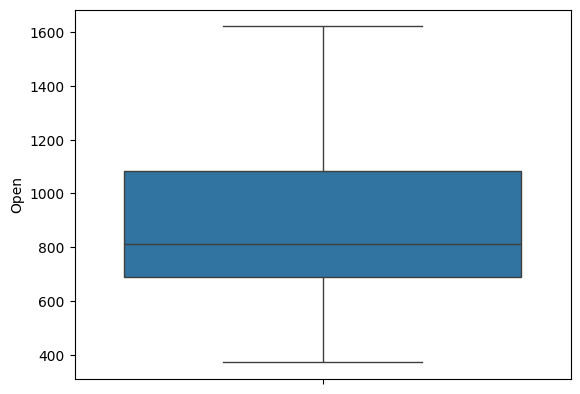

In [179]:
import seaborn as sns

# Check for outliers in Opening Prices
print(stock_data_cp.Open.describe())
sns.boxplot(stock_data_cp["Open"])

count     291.000000
mean      864.874708
std       268.203122
min       372.300000
25%       686.325000
50%       803.250000
75%      1084.675000
max      1607.850000
Name: Close, dtype: float64


<Axes: ylabel='Close'>

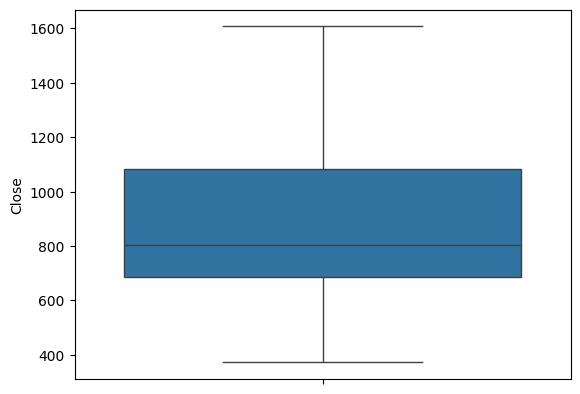

In [180]:
# Check for outliers in Closing Prices
print(stock_data_cp.Close.describe())
sns.boxplot(stock_data_cp['Close'])

count     291.000000
mean      852.937526
std       265.094927
min       365.200000
25%       679.250000
50%       796.000000
75%      1055.500000
max      1600.050000
Name: Low, dtype: float64


<Axes: ylabel='Low'>

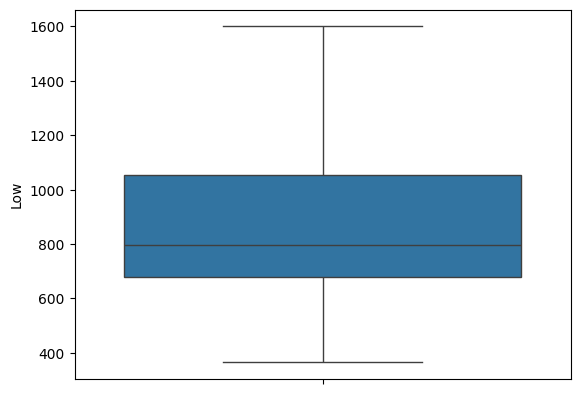

In [181]:
# Check for outliers in Low
print(stock_data_cp.Low.describe())
sns.boxplot(stock_data_cp['Low'])

count     291.000000
mean      883.637285
std       273.510305
min       405.500000
25%       697.400000
50%       819.050000
75%      1116.000000
max      1650.000000
Name: High, dtype: float64


<Axes: ylabel='High'>

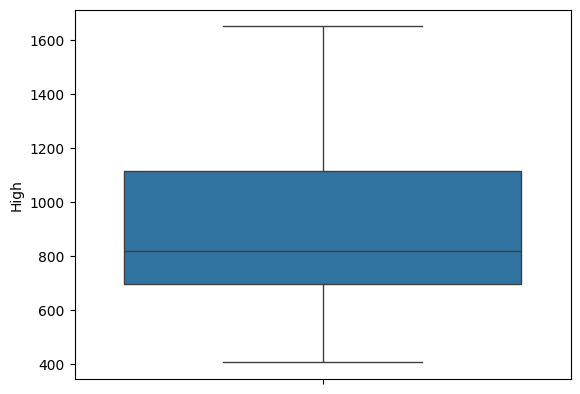

In [182]:
# Check for outliers in High
print(stock_data_cp.High.describe())
sns.boxplot(stock_data_cp['High'])

count       291.000000
mean      40521.305842
std       72049.681325
min        1400.000000
25%        7500.000000
50%       16400.000000
75%       47300.000000
max      843600.000000
Name: Volume, dtype: float64


<Axes: ylabel='Volume'>

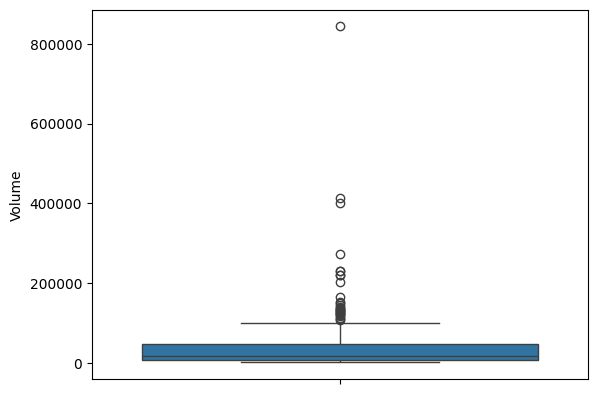

In [183]:
# Check for outliers in Volume
print(stock_data_cp.Volume.describe())
sns.boxplot(stock_data_cp['Volume'])

,Volume
count,291.000000
mean,13145.017182
std,6198.153305
min,1400.000000
25%,7500.000000
50%,16400.000000
75%,16400.000000
max,29400.000000


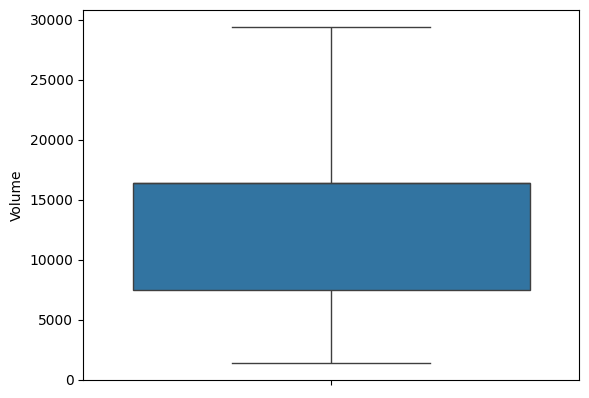

In [184]:
# Replacing Outliers in Volume Variable by Median
stock_data_cp['Volume'] = np.where(stock_data_cp['Volume'] > 30000,
                            stock_data_cp['Volume'].median(),
                            stock_data_cp['Volume'])
sns.boxplot(stock_data_cp["Volume"])
stock_data_cp['Volume'].describe()